In [1]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

In [2]:
df = data.copy()

In [3]:
df = df.set_index("Date")

In [4]:
df.loc['2002-02-14']

Gold_Open        300.000000
Gold_High        300.500000
Gold_Low         299.399994
Gold_Close       299.700012
Gold_Volume       20.000000
DXY              118.430000
SP500           1116.479980
Oil               21.219999
VIX               21.770000
Lag1             299.399994
Lag7             298.200012
MA7              300.085720
MA30             287.063333
EMA20            291.962793
Daily_Return       0.001002
RSI               68.829643
MACD               5.500935
MACD_Signal        4.344156
MACD_Hist          1.156780
BB_Upper         307.481856
BB_Middle        289.115001
BB_Lower         270.748146
ATR                3.761646
Target           298.399994
Name: 2002-02-14, dtype: float64

In [5]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target'],
      dtype='str')

In [6]:
y = df['Target']
X = df.drop(columns=['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Volume', 'ATR', 'Target'])

In [7]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target'],
      dtype='str')

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

s_train = scaler.fit_transform(X_train)
s_test = scaler.transform(X_test)

X_train = pd.DataFrame(s_train, columns = X.columns, index = X_train.index)
X_test = pd.DataFrame(s_test, columns = X.columns, index = X_test.index)

In [10]:
from GoldPricePredictor import GoldPricePredictor

model = GoldPricePredictor()
model.train(X_train, y_train, es_patience=5, lr=0.005)

Epoch 1/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 282959.8750 - mae: 368.9836 - val_loss: 86833.8359 - val_mae: 222.6640
Epoch 2/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26040.4414 - mae: 120.8391 - val_loss: 18267.0859 - val_mae: 103.2346
Epoch 3/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19226.2109 - mae: 103.0622 - val_loss: 18020.0820 - val_mae: 103.5892
Epoch 4/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15654.5020 - mae: 91.8240 - val_loss: 8252.9541 - val_mae: 70.1037
Epoch 5/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14824.8291 - mae: 87.6229 - val_loss: 9042.5859 - val_mae: 73.8341
Epoch 6/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13699.5146 - mae: 85.2597 - val_loss: 6516.4746 - val_mae: 62.5089
Epoch 7/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13635.2012 - mae: 84.5521 - val_loss: 6393.1797 - val_mae: 73.8405
Epoch 8/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13766.5898 - mae: 85.1280 - val_l

RMSE : 80.67548615899948
MAE  : 57.52692622047672
R²   : 0.9931145426030221


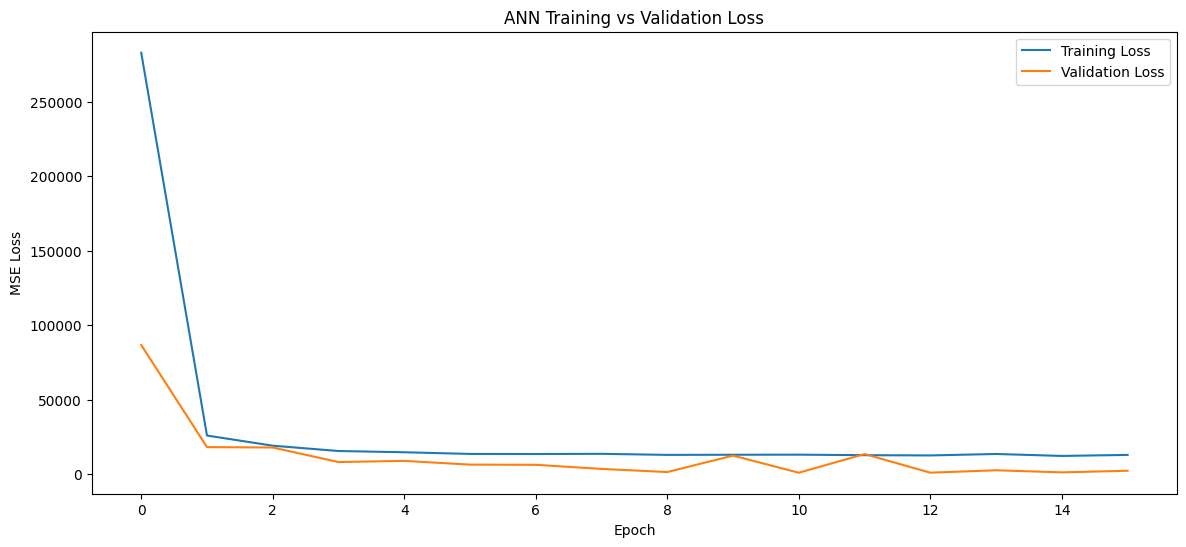

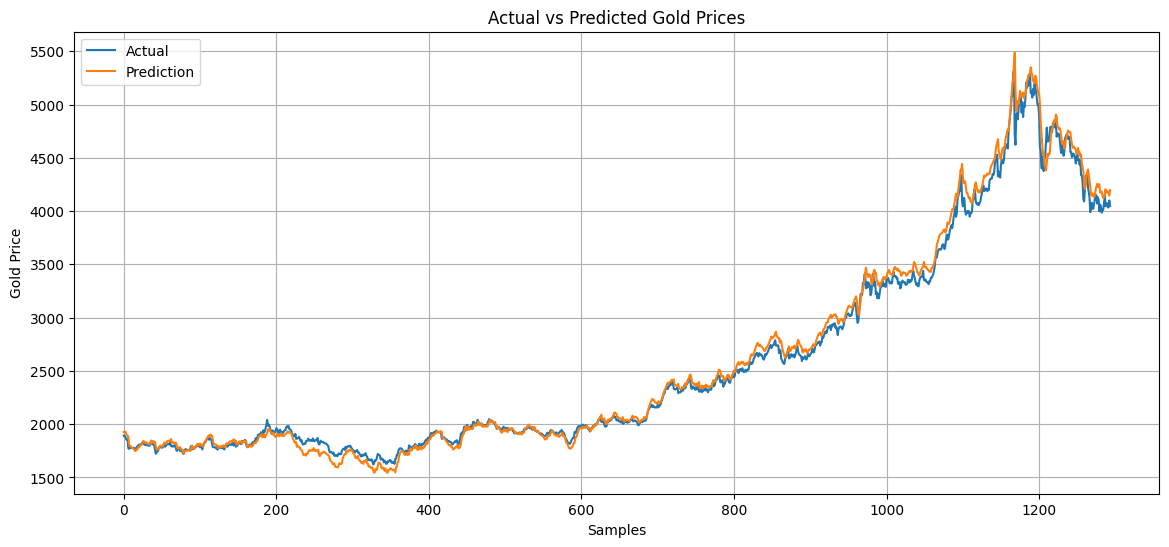

In [11]:
model.evaluate(X_test, y_test)

In [ ]:
latest_data = df.iloc[-1]

forecast_df = model.forecast(
    latest_data=latest_data,
    historical_data=df,
    days=7
)

7-Day Gold Price Forecast
Lowest predicted price : 4197.07
Lowest price date      : 2026-07-31
Highest predicted price: 4844.79
Highest price date     : 2026-08-10


In [13]:
forecast_df

,Date,Predicted_Close
0,2026-07-31,4197.072266
1,2026-08-03,4287.892578
2,2026-08-04,4365.589355
3,2026-08-05,4466.399414
4,2026-08-06,4583.486816
5,2026-08-07,4703.836914
6,2026-08-10,4844.789062


In [14]:
#model.save("gold_model.keras")